# CNN 7.5h Tuning Notebook (Grid + Random Search)

This notebook is separate from your baseline `CNN.ipynb`.

- Data source: `Dataset/audio_active/*_train_temp_full.wav`, `*_val_temp_full.wav`, `*_test_temp_full.wav`
- Split policy: 70/15/15 (already prepared)
- Tuning methods: Grid Search and Random Search

In [45]:
import os
import json
import random
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[Device] Using: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

[Device] Using: cuda
   GPU: NVIDIA GeForce GTX 1650


In [12]:
# Core configuration
from pathlib import Path

SAMPLE_RATE = 16000
SEGMENT_LENGTH = 3
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512

LANG_MAP = {'en': 0, 'ms': 1, 'zh': 2}
LANG_NAMES = ['English', 'Malay', 'Mandarin']

# Early stopping settings used during hyperparameter search.
EARLY_STOP_PATIENCE = 3      # Stop if no validation-accuracy improvement for N consecutive epochs
EARLY_STOP_MIN_DELTA = 0.0   # Minimum accuracy gain to count as an improvement

# Speed settings for search.
# IMPORTANT: Use 0 workers on Windows to avoid DataLoader worker crashes.
TUNING_NUM_WORKERS = 0
TUNING_TRAIN_FRACTION = 0.35
TUNING_VAL_FRACTION = 0.50
TUNING_MAX_TRAIN_BATCHES = 120
TUNING_MAX_VAL_BATCHES = 60

# Dataset routing strategy:
# - tune on 1h for speed/reliability
# - final train/eval on 7.5h
TUNING_SOURCE = '1h'      # options: '1h', '7p5h'
FINAL_RUN_SOURCE = '7p5h' # options: '1h', '7p5h'


def find_project_root_with_audio_active(start_dir: Path) -> Path:
    """Find project root by searching current and parent dirs for Dataset/audio_active."""
    candidates = [start_dir] + list(start_dir.parents)
    for c in candidates:
        audio_dir = c / 'Dataset' / 'audio_active'
        if audio_dir.exists():
            return c
    raise FileNotFoundError(
        f"Could not find Dataset/audio_active from {start_dir} or its parent directories."
    )


PROJECT_ROOT = find_project_root_with_audio_active(Path.cwd())
AUDIO_ACTIVE_DIR = PROJECT_ROOT / 'Dataset' / 'audio_active'
AUDIO_SPLIT_1H_DIR = PROJECT_ROOT / 'Dataset' / 'audio_split'

print(f"[Path] Notebook CWD: {Path.cwd()}")
print(f"[Path] Project root: {PROJECT_ROOT}")
print(f"[Path] Audio active dir (7.5h): {AUDIO_ACTIVE_DIR}")
print(f"[Path] Audio split dir (1h): {AUDIO_SPLIT_1H_DIR}")
print(f"[Early Stop] patience={EARLY_STOP_PATIENCE}, min_delta={EARLY_STOP_MIN_DELTA}")
print(
    f"[Speed] workers={TUNING_NUM_WORKERS}, train_frac={TUNING_TRAIN_FRACTION}, "
    f"val_frac={TUNING_VAL_FRACTION}, max_train_batches={TUNING_MAX_TRAIN_BATCHES}, "
    f"max_val_batches={TUNING_MAX_VAL_BATCHES}"
)
print(f"[Routing] tuning_source={TUNING_SOURCE}, final_source={FINAL_RUN_SOURCE}")


def build_split_paths_7p5h(split_name):
    return {
        lang: AUDIO_ACTIVE_DIR / f'{lang}_{split_name}_temp_full.wav'
        for lang in LANG_MAP
    }


def build_split_paths_1h(split_name):
    return {
        lang: AUDIO_SPLIT_1H_DIR / split_name / f'{lang}_{split_name}.wav'
        for lang in LANG_MAP
    }


split_paths_7p5h = {
    'train': build_split_paths_7p5h('train'),
    'val': build_split_paths_7p5h('val'),
    'test': build_split_paths_7p5h('test'),
}

split_paths_1h = {
    'train': build_split_paths_1h('train'),
    'val': build_split_paths_1h('val'),
    'test': build_split_paths_1h('test'),
}


def check_split_paths(tag, split_paths):
    print(f'[Data] Expected files for {tag}:')
    all_ok = True
    for split_name, lang_paths in split_paths.items():
        status = []
        for lang, p in lang_paths.items():
            ok = p.exists()
            all_ok = all_ok and ok
            status.append(f"{lang.upper()}={'OK' if ok else 'Missing'}")
        print(f"   {split_name.upper()}: " + ', '.join(status))
    return all_ok


ok_7p5h = check_split_paths('7.5h split', split_paths_7p5h)
ok_1h = check_split_paths('1h split', split_paths_1h)

if not ok_7p5h:
    raise FileNotFoundError('Some 7.5h split files are missing.')
if not ok_1h:
    raise FileNotFoundError('Some 1h split files are missing.')

[Path] Notebook CWD: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\CNN
[Path] Project root: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP
[Path] Audio active dir (7.5h): c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\Dataset\audio_active
[Path] Audio split dir (1h): c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\Dataset\audio_split
[Early Stop] patience=3, min_delta=0.0
[Speed] workers=0, train_frac=0.35, val_frac=0.5, max_train_batches=120, max_val_batches=60
[Routing] tuning_source=1h, final_source=7p5h
[Data] Expected files for 7.5h split:
   TRAIN: EN=OK, MS=OK, ZH=OK
   VAL: EN=OK, MS=OK, ZH=OK
   TEST: EN=OK, MS=OK, ZH=OK
[Data] Expected files for 1h split:
   TRAIN: EN=OK, MS=OK, ZH=OK
   VAL: EN=OK, MS=OK, ZH=OK
   TEST: EN=OK, MS=OK, ZH=OK


In [13]:
class AudioSegmentDataset(Dataset):
    def __init__(self, audio_files, labels, segment_length=3, sr=16000, n_mels=128, n_fft=1024, hop_length=512, augment=False):
        self.audio_files = audio_files
        self.labels = labels
        self.segment_length = segment_length
        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.segment_samples = segment_length * sr
        self.augment = augment

        self.segments = []
        for idx, file_path in enumerate(audio_files):
            duration = librosa.get_duration(path=file_path)
            num_segments = int(duration // segment_length)
            for seg_idx in range(num_segments):
                self.segments.append((idx, seg_idx))

        print(f'Dataset: {len(self.audio_files)} files -> {len(self.segments)} segments')

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        file_idx, seg_idx = self.segments[idx]
        file_path = self.audio_files[file_idx]
        label = self.labels[file_idx]

        offset = seg_idx * self.segment_length
        y, _ = librosa.load(file_path, sr=self.sr, offset=offset, duration=self.segment_length, mono=True)

        if len(y) < self.segment_samples:
            y = np.pad(y, (0, self.segment_samples - len(y)))
        else:
            y = y[:self.segment_samples]

        if self.augment:
            y = y * np.random.uniform(0.8, 1.2)

        mel_spec = librosa.feature.melspectrogram(y=y, sr=self.sr, n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8)

        return torch.FloatTensor(mel_spec_db).unsqueeze(0), label

In [14]:
def files_and_labels(split_name, source='7p5h'):
    if source == '7p5h':
        split_paths = split_paths_7p5h
    elif source == '1h':
        split_paths = split_paths_1h
    else:
        raise ValueError(f'Unknown source: {source}')

    files = []
    labels = []
    for lang, lang_id in LANG_MAP.items():
        p = split_paths[split_name][lang]
        files.append(str(p))
        labels.append(lang_id)
    return files, labels


# Build both datasets once, then route tuning/final flows by source choice.
train_files_7p5h, train_labels_7p5h = files_and_labels('train', source='7p5h')
val_files_7p5h, val_labels_7p5h = files_and_labels('val', source='7p5h')
test_files_7p5h, test_labels_7p5h = files_and_labels('test', source='7p5h')

train_files_1h, train_labels_1h = files_and_labels('train', source='1h')
val_files_1h, val_labels_1h = files_and_labels('val', source='1h')
test_files_1h, test_labels_1h = files_and_labels('test', source='1h')


train_dataset_7p5h = AudioSegmentDataset(train_files_7p5h, train_labels_7p5h, SEGMENT_LENGTH, SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, augment=True)
val_dataset_7p5h = AudioSegmentDataset(val_files_7p5h, val_labels_7p5h, SEGMENT_LENGTH, SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, augment=False)
test_dataset_7p5h = AudioSegmentDataset(test_files_7p5h, test_labels_7p5h, SEGMENT_LENGTH, SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, augment=False)

train_dataset_1h = AudioSegmentDataset(train_files_1h, train_labels_1h, SEGMENT_LENGTH, SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, augment=True)
val_dataset_1h = AudioSegmentDataset(val_files_1h, val_labels_1h, SEGMENT_LENGTH, SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, augment=False)
test_dataset_1h = AudioSegmentDataset(test_files_1h, test_labels_1h, SEGMENT_LENGTH, SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, augment=False)


if TUNING_SOURCE == '1h':
    train_dataset_tuning, val_dataset_tuning = train_dataset_1h, val_dataset_1h
elif TUNING_SOURCE == '7p5h':
    train_dataset_tuning, val_dataset_tuning = train_dataset_7p5h, val_dataset_7p5h
else:
    raise ValueError(f'Unsupported TUNING_SOURCE: {TUNING_SOURCE}')

if FINAL_RUN_SOURCE == '1h':
    train_files_final, train_labels_final = train_files_1h, train_labels_1h
    val_files_final, val_labels_final = val_files_1h, val_labels_1h
    test_dataset_final = test_dataset_1h
elif FINAL_RUN_SOURCE == '7p5h':
    train_files_final, train_labels_final = train_files_7p5h, train_labels_7p5h
    val_files_final, val_labels_final = val_files_7p5h, val_labels_7p5h
    test_dataset_final = test_dataset_7p5h
else:
    raise ValueError(f'Unsupported FINAL_RUN_SOURCE: {FINAL_RUN_SOURCE}')

print('[Data] Datasets built for both 1h and 7.5h.')
print(f"[Routing] Tuning dataset source: {TUNING_SOURCE}")
print(f"[Routing] Final run dataset source: {FINAL_RUN_SOURCE}")

Dataset: 3 files -> 18905 segments
Dataset: 3 files -> 4050 segments
Dataset: 3 files -> 4050 segments
Dataset: 3 files -> 1512 segments
Dataset: 3 files -> 324 segments
Dataset: 3 files -> 324 segments
[Data] Datasets built for both 1h and 7.5h.
[Routing] Tuning dataset source: 1h
[Routing] Final run dataset source: 7p5h


## CNN Model Architecture

4-layer 2D Convolutional Neural Network:
- Input: (batch, 1, 128, time_frames) mel-spectrogram
- Conv blocks with BatchNorm + ReLU + MaxPool
- Global average pooling
- Fully connected layers with dropout
- Output: 3 classes (EN/MS/ZH)

In [15]:
class MelSpectrogramCNN(nn.Module):
    def __init__(self, num_classes=3, dropout_fc1=0.5, dropout_fc2=0.3):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.conv_block2 = nn.Sequential(nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.conv_block3 = nn.Sequential(nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))
        self.conv_block4 = nn.Sequential(nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)))
        self.fc = nn.Sequential(
            nn.Dropout(dropout_fc1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_fc2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

## Tuning Helper Function

`run_train_eval(...)` is a reusable evaluator.

- It trains a fresh model for one hyperparameter configuration.
- It evaluates on validation data each epoch.
- It uses **early stopping** when validation accuracy does not improve for a configured number of consecutive epochs.
- It returns the **best validation accuracy** for that configuration.

This function itself is **not** grid search or random search; it is called by those search loops.

In [16]:
def run_train_eval(config, train_ds, val_ds, seed=42):
    """
    Train and validate one CNN configuration.

    Args:
        config: dict with keys ['lr', 'batch_size', 'epochs', 'weight_decay', 'dropout_fc1', 'dropout_fc2']
        train_ds: training dataset
        val_ds: validation dataset
        seed: random seed for reproducibility

    Returns:
        best_val_acc (float): highest validation accuracy observed across epochs
    """
    # Reproducibility across Python, NumPy, and PyTorch.
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # Optional speed knobs for tuning runs.
    train_fraction = float(config.get('train_fraction', TUNING_TRAIN_FRACTION))
    val_fraction = float(config.get('val_fraction', TUNING_VAL_FRACTION))
    max_train_batches = config.get('max_train_batches', TUNING_MAX_TRAIN_BATCHES)
    max_val_batches = config.get('max_val_batches', TUNING_MAX_VAL_BATCHES)
    num_workers = int(config.get('num_workers', TUNING_NUM_WORKERS))

    # Windows is commonly unstable with librosa-heavy DataLoader workers.
    if os.name == 'nt' and num_workers > 0:
        print(f"[Loader] Windows detected. Forcing num_workers=0 (requested {num_workers}).")
        num_workers = 0

    train_ds_eff = train_ds
    val_ds_eff = val_ds

    # Subsample datasets per trial to speed up hyperparameter search.
    if 0 < train_fraction < 1.0:
        train_n = max(1, int(len(train_ds) * train_fraction))
        train_idx = np.random.choice(len(train_ds), size=train_n, replace=False)
        train_ds_eff = Subset(train_ds, train_idx.tolist())

    if 0 < val_fraction < 1.0:
        val_n = max(1, int(len(val_ds) * val_fraction))
        val_idx = np.random.choice(len(val_ds), size=val_n, replace=False)
        val_ds_eff = Subset(val_ds, val_idx.tolist())

    # DataLoaders are rebuilt per trial because batch size is a tuned parameter.
    def make_loaders(local_workers):
        train_loader_local = DataLoader(
            train_ds_eff,
            batch_size=config['batch_size'],
            shuffle=True,
            num_workers=local_workers,
            pin_memory=torch.cuda.is_available()
        )
        val_loader_local = DataLoader(
            val_ds_eff,
            batch_size=config['batch_size'],
            shuffle=False,
            num_workers=local_workers,
            pin_memory=torch.cuda.is_available()
        )
        return train_loader_local, val_loader_local

    train_loader, val_loader = make_loaders(num_workers)

    # Fresh model for each trial (important for fair comparison).
    model = MelSpectrogramCNN(
        num_classes=len(LANG_MAP),
        dropout_fc1=config['dropout_fc1'],
        dropout_fc2=config['dropout_fc2']
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )

    # Early stopping controls (fallback to global defaults).
    patience = int(config.get('patience', EARLY_STOP_PATIENCE))
    min_delta = float(config.get('min_delta', EARLY_STOP_MIN_DELTA))

    best_val_acc = 0.0
    no_improve_epochs = 0

    # Train for N epochs, validate each epoch, and stop early when no improvement persists.
    for epoch in range(config['epochs']):
        model.train()
        try:
            for batch_i, (inputs, labels) in enumerate(train_loader):
                if max_train_batches is not None and batch_i >= int(max_train_batches):
                    break
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
        except RuntimeError as e:
            if 'DataLoader worker' in str(e) and num_workers != 0:
                print('[Loader] Worker crashed. Retrying this trial with num_workers=0.')
                num_workers = 0
                train_loader, val_loader = make_loaders(num_workers)
                for batch_i, (inputs, labels) in enumerate(train_loader):
                    if max_train_batches is not None and batch_i >= int(max_train_batches):
                        break
                    inputs, labels = inputs.to(device), labels.to(device)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()
            else:
                raise

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_i, (inputs, labels) in enumerate(val_loader):
                if max_val_batches is not None and batch_i >= int(max_val_batches):
                    break
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)

        if total == 0:
            continue

        val_acc = 100.0 * correct / total

        if val_acc > (best_val_acc + min_delta):
            best_val_acc = val_acc
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        if no_improve_epochs >= patience:
            print(
                f"[Early Stop] epoch={epoch + 1}, best_val_acc={best_val_acc:.2f}% "
                f"(no improvement for {patience} consecutive epochs)"
            )
            break

    return best_val_acc

## Grid Search (3 Tuned Hyperparameters)

This grid search tunes only:

- `lr`
- `batch_size`
- `epochs`

The following are fixed during search:

- `weight_decay = 1e-5`
- `dropout_fc1 = 0.5`
- `dropout_fc2 = 0.3`

This keeps the search manageable while still finding strong training settings.

In [ ]:
RUN_GRID_SEARCH = True  # Set to False to skip exhaustive search

# Tune only these 3 hyperparameters.
GRID_LR_OPTIONS = [1e-4, 5e-4, 1e-3, 1e-2]
GRID_BATCH_OPTIONS = [16, 24, 32]
GRID_EPOCH_OPTIONS = [20, 25, 30]

# Keep the rest fixed during search.
FIXED_WEIGHT_DECAY = 1e-5
FIXED_DROPOUT_FC1 = 0.5
FIXED_DROPOUT_FC2 = 0.3

if RUN_GRID_SEARCH:
    print('[Tuning] Starting CNN hyperparameter GRID search (3 params)...')
    print(f'[Tuning Source] {TUNING_SOURCE}')
    print(f'  Learning rates: {GRID_LR_OPTIONS}')
    print(f'  Batch sizes: {GRID_BATCH_OPTIONS}')
    print(f'  Epochs: {GRID_EPOCH_OPTIONS}\n')
    print('  Fixed params:')
    print(f'    weight_decay={FIXED_WEIGHT_DECAY}')
    print(f'    dropout_fc1={FIXED_DROPOUT_FC1}')
    print(f'    dropout_fc2={FIXED_DROPOUT_FC2}')

    # 4 x 3 x 3 = 36 total configurations.
    grid_configs = [
        {
            'lr': lr,
            'batch_size': bs,
            'epochs': ep,
            'weight_decay': FIXED_WEIGHT_DECAY,
            'dropout_fc1': FIXED_DROPOUT_FC1,
            'dropout_fc2': FIXED_DROPOUT_FC2,
            # Speed controls for tuning-only runs.
            'train_fraction': TUNING_TRAIN_FRACTION,
            'val_fraction': TUNING_VAL_FRACTION,
            'max_train_batches': TUNING_MAX_TRAIN_BATCHES,
            'max_val_batches': TUNING_MAX_VAL_BATCHES,
            'num_workers': TUNING_NUM_WORKERS,
        }
        for lr in GRID_LR_OPTIONS
        for bs in GRID_BATCH_OPTIONS
        for ep in GRID_EPOCH_OPTIONS
    ]

    print(f"\n[Grid] Total configs: {len(grid_configs)}")

    grid_results = []
    best_tuning_grid = None

    for i, cfg in enumerate(tqdm(grid_configs, desc='Grid Search', unit='cfg'), start=1):
        print(
            f"[Testing {i}/{len(grid_configs)}] "
            f"lr={cfg['lr']}, batch={cfg['batch_size']}, epochs={cfg['epochs']}"
        )

        # Tune on selected source (1h recommended).
        temp_best_val = run_train_eval(cfg, train_dataset_tuning, val_dataset_tuning, seed=42)

        row = dict(cfg)
        row['val_acc'] = temp_best_val
        grid_results.append(row)

        print(f"  -> Val acc: {temp_best_val:.2f}%\n")

        if best_tuning_grid is None or temp_best_val > best_tuning_grid['val_acc']:
            best_tuning_grid = row

    grid_results_df = pd.DataFrame(grid_results).sort_values('val_acc', ascending=False).reset_index(drop=True)

    print('[Tuning] Grid search complete.')
    print(
        f"[Best Grid] lr={best_tuning_grid['lr']}, batch={best_tuning_grid['batch_size']}, "
        f"epochs={best_tuning_grid['epochs']}, val_acc={best_tuning_grid['val_acc']:.2f}%"
    )

    print('\n[Top 5 Grid Configs]')
    display(grid_results_df.head(5))
else:
    print('[Skipped] Grid search disabled.')

[Tuning] Starting CNN hyperparameter GRID search (3 params)...
[Tuning Source] 1h
  Learning rates: [0.0001, 0.0005, 0.001, 0.01]
  Batch sizes: [16, 24, 32]
  Epochs: [20, 25, 30]

  Fixed params:
    weight_decay=1e-05
    dropout_fc1=0.5
    dropout_fc2=0.3

[Grid] Total configs: 36


Grid Search:   0%|          | 0/36 [00:00<?, ?cfg/s]

[Testing 1/36] lr=0.0001, batch=16, epochs=20
[Early Stop] epoch=9, best_val_acc=50.62% (no improvement for 3 consecutive epochs)
  -> Val acc: 50.62%

[Testing 2/36] lr=0.0001, batch=16, epochs=25
[Early Stop] epoch=9, best_val_acc=51.23% (no improvement for 3 consecutive epochs)
  -> Val acc: 51.23%

[Testing 3/36] lr=0.0001, batch=16, epochs=30
[Early Stop] epoch=9, best_val_acc=50.00% (no improvement for 3 consecutive epochs)
  -> Val acc: 50.00%

[Testing 4/36] lr=0.0001, batch=24, epochs=20
[Early Stop] epoch=10, best_val_acc=51.23% (no improvement for 3 consecutive epochs)
  -> Val acc: 51.23%

[Testing 5/36] lr=0.0001, batch=24, epochs=25
[Early Stop] epoch=10, best_val_acc=51.23% (no improvement for 3 consecutive epochs)
  -> Val acc: 51.23%

[Testing 6/36] lr=0.0001, batch=24, epochs=30
[Early Stop] epoch=10, best_val_acc=51.23% (no improvement for 3 consecutive epochs)
  -> Val acc: 51.23%

[Testing 7/36] lr=0.0001, batch=32, epochs=20
[Early Stop] epoch=10, best_val_acc=50.

,lr,batch_size,epochs,weight_decay,dropout_fc1,dropout_fc2,train_fraction,val_fraction,max_train_batches,max_val_batches,num_workers,val_acc
0,0.0010,16,20,0.00001,0.5,0.3,0.35,0.5,120,60,0,58.641975
1,0.0005,16,20,0.00001,0.5,0.3,0.35,0.5,120,60,0,56.790123
2,0.0010,16,30,0.00001,0.5,0.3,0.35,0.5,120,60,0,55.555556
3,0.0010,32,20,0.00001,0.5,0.3,0.35,0.5,120,60,0,52.469136
4,0.0010,32,25,0.00001,0.5,0.3,0.35,0.5,120,60,0,52.469136


## Random Search (Broader Search Space)

This random search samples a **broader and different** space from grid search.

- Grid search checks a small, structured range.
- Random search explores a wider space with more variation.

This is intentional so the two searches test different regions.

In [ ]:
RUN_RANDOM_SEARCH = True  # Set to False to skip sampled search

# Broader random search space than grid search.
# We sample from wider ranges and allow different values so the search is meaningful.
RANDOM_LR_MIN = 1e-5
RANDOM_LR_MAX = 5e-3
RANDOM_BATCH_OPTIONS = [8, 12, 16, 24, 32, 48]
RANDOM_EPOCH_OPTIONS = [12, 16, 20, 24, 28, 32]
RANDOM_WEIGHT_DECAY_OPTIONS = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
RANDOM_DROPOUT_FC1_OPTIONS = [0.3, 0.4, 0.5, 0.6, 0.7]
RANDOM_DROPOUT_FC2_OPTIONS = [0.1, 0.2, 0.3, 0.4, 0.5]

# Fewer trials, but broader coverage.
N_RANDOM_TRIALS = 16


def sample_log_uniform(low, high):
    return float(10 ** np.random.uniform(np.log10(low), np.log10(high)))


if RUN_RANDOM_SEARCH:
    print('[Tuning] Starting CNN hyperparameter RANDOM search (broader space)...')
    print(f'[Tuning Source] {TUNING_SOURCE}')
    print(f'[Random] Number of trials: {N_RANDOM_TRIALS}')
    print('  Search space:')
    print(f'    lr in [{RANDOM_LR_MIN}, {RANDOM_LR_MAX}] (log-uniform)')
    print(f'    batch_size in {RANDOM_BATCH_OPTIONS}')
    print(f'    epochs in {RANDOM_EPOCH_OPTIONS}')
    print(f'    weight_decay in {RANDOM_WEIGHT_DECAY_OPTIONS}')
    print(f'    dropout_fc1 in {RANDOM_DROPOUT_FC1_OPTIONS}')
    print(f'    dropout_fc2 in {RANDOM_DROPOUT_FC2_OPTIONS}')

    random_results = []
    best_tuning_random = None

    for i in tqdm(range(1, N_RANDOM_TRIALS + 1), desc='Random Search', unit='trial'):
        cfg = {
            'lr': sample_log_uniform(RANDOM_LR_MIN, RANDOM_LR_MAX),
            'batch_size': random.choice(RANDOM_BATCH_OPTIONS),
            'epochs': random.choice(RANDOM_EPOCH_OPTIONS),
            'weight_decay': random.choice(RANDOM_WEIGHT_DECAY_OPTIONS),
            'dropout_fc1': random.choice(RANDOM_DROPOUT_FC1_OPTIONS),
            'dropout_fc2': random.choice(RANDOM_DROPOUT_FC2_OPTIONS),
            # Speed controls for tuning-only runs.
            'train_fraction': TUNING_TRAIN_FRACTION,
            'val_fraction': TUNING_VAL_FRACTION,
            'max_train_batches': TUNING_MAX_TRAIN_BATCHES,
            'max_val_batches': TUNING_MAX_VAL_BATCHES,
            'num_workers': TUNING_NUM_WORKERS,
        }

        print(
            f"[Random {i}/{N_RANDOM_TRIALS}] Testing: "
            f"lr={cfg['lr']:.2e}, batch={cfg['batch_size']}, epochs={cfg['epochs']}, "
            f"wd={cfg['weight_decay']}, d1={cfg['dropout_fc1']}, d2={cfg['dropout_fc2']}"
        )

        # Tune on selected source (1h recommended).
        temp_best_val = run_train_eval(cfg, train_dataset_tuning, val_dataset_tuning, seed=42 + i)

        row = dict(cfg)
        row['val_acc'] = temp_best_val
        random_results.append(row)

        print(f"  -> Val acc: {temp_best_val:.2f}%\n")

        if best_tuning_random is None or temp_best_val > best_tuning_random['val_acc']:
            best_tuning_random = row

    random_results_df = pd.DataFrame(random_results).sort_values('val_acc', ascending=False).reset_index(drop=True)

    print('[Tuning] Random search complete.')
    print(
        f"[Best Random] lr={best_tuning_random['lr']:.2e}, batch={best_tuning_random['batch_size']}, "
        f"epochs={best_tuning_random['epochs']}, wd={best_tuning_random['weight_decay']}, "
        f"dropout1={best_tuning_random['dropout_fc1']}, dropout2={best_tuning_random['dropout_fc2']}, "
        f"val_acc={best_tuning_random['val_acc']:.2f}%"
    )

    print('\n[Top 5 Random Configs]')
    display(random_results_df.head(5))
else:
    print('[Skipped] Random search disabled.')

[Tuning] Starting CNN hyperparameter RANDOM search (broader space)...
[Tuning Source] 1h
[Random] Number of trials: 16
  Search space:
    lr in [1e-05, 0.005] (log-uniform)
    batch_size in [8, 12, 16, 24, 32, 48]
    epochs in [12, 16, 20, 24, 28, 32]
    weight_decay in [0.0, 1e-06, 1e-05, 0.0001, 0.001]
    dropout_fc1 in [0.3, 0.4, 0.5, 0.6, 0.7]
    dropout_fc2 in [0.1, 0.2, 0.3, 0.4, 0.5]


Random Search:   0%|          | 0/16 [00:00<?, ?trial/s]

[Random 1/16] Testing: lr=8.84e-04, batch=32, epochs=16, wd=0.0, d1=0.4, d2=0.4
[Early Stop] epoch=7, best_val_acc=45.68% (no improvement for 3 consecutive epochs)
  -> Val acc: 45.68%

[Random 2/16] Testing: lr=7.91e-04, batch=8, epochs=20, wd=1e-06, d1=0.6, d2=0.3
[Early Stop] epoch=6, best_val_acc=48.15% (no improvement for 3 consecutive epochs)
  -> Val acc: 48.15%

[Random 3/16] Testing: lr=2.00e-04, batch=24, epochs=28, wd=0.001, d1=0.3, d2=0.2
[Early Stop] epoch=7, best_val_acc=53.70% (no improvement for 3 consecutive epochs)
  -> Val acc: 53.70%

[Random 4/16] Testing: lr=2.03e-04, batch=16, epochs=24, wd=0.0001, d1=0.5, d2=0.1
[Early Stop] epoch=14, best_val_acc=54.94% (no improvement for 3 consecutive epochs)
  -> Val acc: 54.94%

[Random 5/16] Testing: lr=1.05e-03, batch=8, epochs=24, wd=0.0, d1=0.7, d2=0.5
[Early Stop] epoch=10, best_val_acc=51.23% (no improvement for 3 consecutive epochs)
  -> Val acc: 51.23%

[Random 6/16] Testing: lr=3.43e-05, batch=16, epochs=12, wd=0.0

,lr,batch_size,epochs,weight_decay,dropout_fc1,dropout_fc2,train_fraction,val_fraction,max_train_batches,max_val_batches,num_workers,val_acc
0,0.000392,8,16,0.000001,0.5,0.1,0.35,0.5,120,60,0,61.728395
1,0.001074,8,20,0.000100,0.3,0.3,0.35,0.5,120,60,0,61.111111
2,0.000102,8,20,0.001000,0.7,0.1,0.35,0.5,120,60,0,61.111111
3,0.003110,32,16,0.000100,0.7,0.4,0.35,0.5,120,60,0,56.172840
4,0.000203,16,24,0.000100,0.5,0.1,0.35,0.5,120,60,0,54.938272


## Select Best Configuration

This cell chooses the best tuning result and stores it in `best_config` for final training.

It works whether you ran grid search, random search, or both.

In [24]:
tuning_candidates = []

if RUN_GRID_SEARCH and 'grid_results_df' in globals() and not grid_results_df.empty:
    best_grid = grid_results_df.iloc[0].to_dict()
    tuning_candidates.append(('grid', best_grid))

if RUN_RANDOM_SEARCH and 'random_results_df' in globals() and not random_results_df.empty:
    best_random = random_results_df.iloc[0].to_dict()
    tuning_candidates.append(('random', best_random))

if not tuning_candidates:
    raise RuntimeError('No tuning results found. Run grid search or random search first.')

best_source, best_config = max(tuning_candidates, key=lambda item: item[1]['val_acc'])

print(f'[Best Config] Selected from {best_source} search')
print(
    f"  lr={best_config['lr']}, batch={best_config['batch_size']}, epochs={best_config['epochs']}, "
    f"weight_decay={best_config['weight_decay']}, dropout_fc1={best_config['dropout_fc1']}, "
    f"dropout_fc2={best_config['dropout_fc2']}, val_acc={best_config['val_acc']:.2f}%"
)

[Best Config] Selected from random search
  lr=0.00039189974186350576, batch=8.0, epochs=16.0, weight_decay=1e-06, dropout_fc1=0.5, dropout_fc2=0.1, val_acc=61.73%


## Hyperparameter Visualization (Grid vs Random)

This section compares search coverage and performance between grid search and random search.

It only visualizes in the notebook and does not save image files.

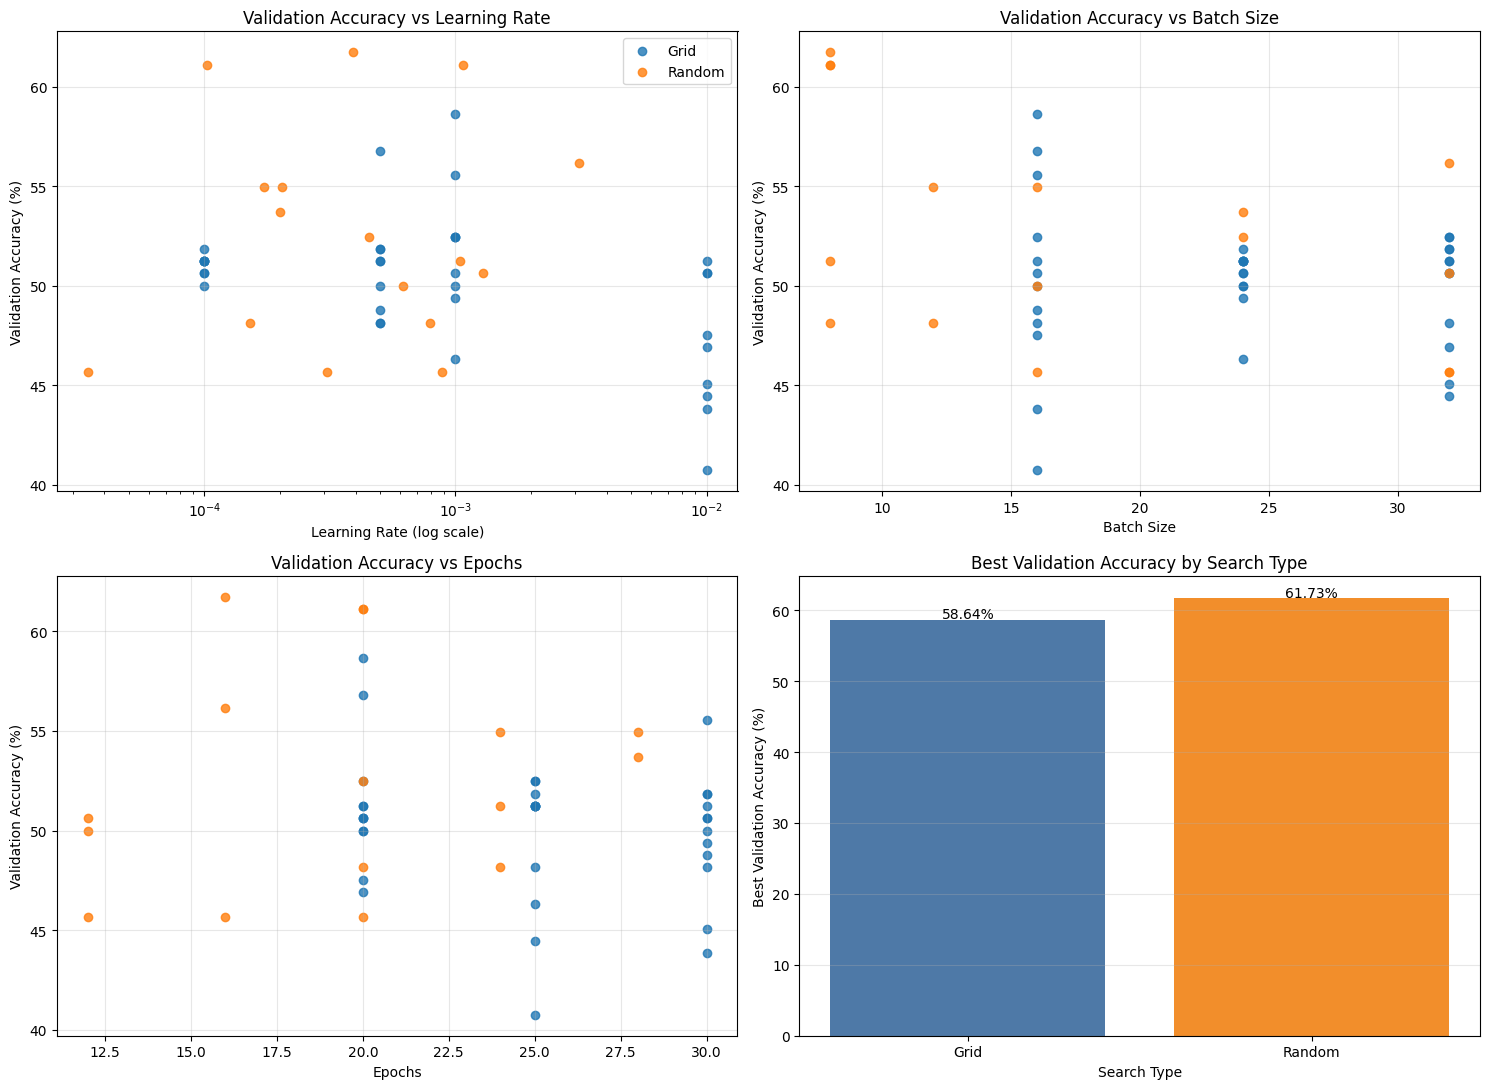

Top 5 configurations per search type:


,search_type,val_acc,lr,batch_size,epochs,weight_decay,dropout_fc1,dropout_fc2
0,Random,61.728395,0.000392,8,16,0.000001,0.5,0.1
1,Random,61.111111,0.001074,8,20,0.000100,0.3,0.3
2,Random,61.111111,0.000102,8,20,0.001000,0.7,0.1
3,Grid,58.641975,0.001000,16,20,0.000010,0.5,0.3
4,Grid,56.790123,0.000500,16,20,0.000010,0.5,0.3
5,Random,56.172840,0.003110,32,16,0.000100,0.7,0.4
6,Grid,55.555556,0.001000,16,30,0.000010,0.5,0.3
7,Random,54.938272,0.000172,12,28,0.001000,0.4,0.2
8,Grid,52.469136,0.001000,16,25,0.000010,0.5,0.3
9,Grid,52.469136,0.001000,32,20,0.000010,0.5,0.3


In [46]:
# Compare hyperparameter performance and distributions for grid vs random.
if ('grid_results_df' not in globals()) and ('random_results_df' not in globals()):
    raise RuntimeError('No tuning results found. Run grid search and/or random search first.')

plot_rows = []
if 'grid_results_df' in globals() and isinstance(grid_results_df, pd.DataFrame) and not grid_results_df.empty:
    g = grid_results_df.copy()
    g['search_type'] = 'Grid'
    plot_rows.append(g)
if 'random_results_df' in globals() and isinstance(random_results_df, pd.DataFrame) and not random_results_df.empty:
    r = random_results_df.copy()
    r['search_type'] = 'Random'
    plot_rows.append(r)

if not plot_rows:
    raise RuntimeError('No non-empty tuning DataFrames available to visualize.')

viz_df = pd.concat(plot_rows, ignore_index=True)
viz_df['lr'] = pd.to_numeric(viz_df['lr'], errors='coerce')
viz_df['batch_size'] = pd.to_numeric(viz_df['batch_size'], errors='coerce')
viz_df['epochs'] = pd.to_numeric(viz_df['epochs'], errors='coerce')
viz_df['weight_decay'] = pd.to_numeric(viz_df['weight_decay'], errors='coerce')
viz_df['dropout_fc1'] = pd.to_numeric(viz_df['dropout_fc1'], errors='coerce')
viz_df['dropout_fc2'] = pd.to_numeric(viz_df['dropout_fc2'], errors='coerce')
viz_df['val_acc'] = pd.to_numeric(viz_df['val_acc'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for search_name, subset in viz_df.groupby('search_type'):
    axes[0, 0].scatter(subset['lr'], subset['val_acc'], alpha=0.8, label=search_name)
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('Validation Accuracy vs Learning Rate')
axes[0, 0].set_xlabel('Learning Rate (log scale)')
axes[0, 0].set_ylabel('Validation Accuracy (%)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

for search_name, subset in viz_df.groupby('search_type'):
    axes[0, 1].scatter(subset['batch_size'], subset['val_acc'], alpha=0.8, label=search_name)
axes[0, 1].set_title('Validation Accuracy vs Batch Size')
axes[0, 1].set_xlabel('Batch Size')
axes[0, 1].set_ylabel('Validation Accuracy (%)')
axes[0, 1].grid(True, alpha=0.3)

for search_name, subset in viz_df.groupby('search_type'):
    axes[1, 0].scatter(subset['epochs'], subset['val_acc'], alpha=0.8, label=search_name)
axes[1, 0].set_title('Validation Accuracy vs Epochs')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Validation Accuracy (%)')
axes[1, 0].grid(True, alpha=0.3)

best_per_search = viz_df.sort_values('val_acc', ascending=False).groupby('search_type', as_index=False).first()
axes[1, 1].bar(best_per_search['search_type'], best_per_search['val_acc'], color=['#4e79a7', '#f28e2b'])
axes[1, 1].set_title('Best Validation Accuracy by Search Type')
axes[1, 1].set_xlabel('Search Type')
axes[1, 1].set_ylabel('Best Validation Accuracy (%)')
axes[1, 1].grid(True, axis='y', alpha=0.3)

for i, row in best_per_search.iterrows():
    axes[1, 1].text(i, row['val_acc'] + 0.2, f"{row['val_acc']:.2f}%", ha='center')

plt.tight_layout()
plt.show()

print('Top 5 configurations per search type:')
display(
    viz_df.sort_values('val_acc', ascending=False)
    .groupby('search_type', group_keys=False)
    .head(5)
    .reset_index(drop=True)
    [['search_type', 'val_acc', 'lr', 'batch_size', 'epochs', 'weight_decay', 'dropout_fc1', 'dropout_fc2']]
)

## Final Evaluation Helpers

The next three cells evaluate the saved model separately for English, Malay, and Mandarin.

This keeps each cell shorter and avoids waiting for the full combined evaluation in one block.

The results are also saved in the project root directory.

In [25]:
# Final train on selected FINAL_RUN_SOURCE and save the trained model.
def merge_files_labels(files_a, labels_a, files_b, labels_b):
    return files_a + files_b, labels_a + labels_b

print(f"[Final Run Source] {FINAL_RUN_SOURCE}")

# Combine train + val for the selected final source.
trainval_files, trainval_labels = merge_files_labels(
    train_files_final, train_labels_final,
    val_files_final, val_labels_final
)

trainval_dataset = AudioSegmentDataset(
    trainval_files, trainval_labels,
    SEGMENT_LENGTH, SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, augment=True
)

final_batch_size = int(best_config['batch_size'])
final_epochs = int(best_config['epochs'])

trainval_loader = DataLoader(trainval_dataset, batch_size=final_batch_size, shuffle=True, num_workers=0)

model = MelSpectrogramCNN(
    num_classes=len(LANG_MAP),
    dropout_fc1=float(best_config['dropout_fc1']),
    dropout_fc2=float(best_config['dropout_fc2'])
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=float(best_config['lr']), weight_decay=float(best_config['weight_decay']))

for epoch in range(final_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in trainval_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{final_epochs} | Loss: {running_loss/len(trainval_loader):.4f}")

# Save the final model to the project root so it is easy to find later.
model_path = PROJECT_ROOT / 'cnn_7p5h_best_model.pth'
config_path = PROJECT_ROOT / 'cnn_7p5h_best_config.json'

model.eval()
model_config = {
    'tuning_source': TUNING_SOURCE,
    'final_run_source': FINAL_RUN_SOURCE,
    'best_config': best_config,
    'language_names': LANG_NAMES,
}

with open(config_path, 'w') as f:
    json.dump(model_config, f, indent=2)

torch.save(model.state_dict(), model_path)
print(f'Saved model to: {model_path}')
print(f'Saved config to: {config_path}')

[Final Run Source] 7p5h
Dataset: 6 files -> 22955 segments
Epoch 1/16 | Loss: 0.8603
Epoch 2/16 | Loss: 0.7233
Epoch 3/16 | Loss: 0.6491
Epoch 4/16 | Loss: 0.5879
Epoch 5/16 | Loss: 0.5510
Epoch 6/16 | Loss: 0.5121
Epoch 7/16 | Loss: 0.4843
Epoch 8/16 | Loss: 0.4527
Epoch 9/16 | Loss: 0.4252
Epoch 10/16 | Loss: 0.3985
Epoch 11/16 | Loss: 0.3865
Epoch 12/16 | Loss: 0.3669
Epoch 13/16 | Loss: 0.3452
Epoch 14/16 | Loss: 0.3231
Epoch 15/16 | Loss: 0.3088
Epoch 16/16 | Loss: 0.2891
Saved model to: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\cnn_7p5h_best_model.pth
Saved config to: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\cnn_7p5h_best_config.json


In [47]:
# Helper for per-language evaluation and reporting.
from sklearn.metrics import classification_report, confusion_matrix

language_eval_results = {}


def evaluate_language_subset(lang_name, lang_id, test_dataset, batch_size, model_path, output_root):
    """Evaluate the saved model on one language subset and print metrics/plots."""
    subset_indices = [
        i for i, (file_idx, seg_idx) in enumerate(test_dataset.segments)
        if test_dataset.labels[file_idx] == lang_id
    ]

    if len(subset_indices) == 0:
        raise RuntimeError(f'No test samples found for {lang_name}.')

    subset_dataset = torch.utils.data.Subset(test_dataset, subset_indices)
    subset_loader = DataLoader(subset_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    local_model = MelSpectrogramCNN(
        num_classes=len(LANG_MAP),
        dropout_fc1=float(best_config['dropout_fc1']),
        dropout_fc2=float(best_config['dropout_fc2'])
    ).to(device)
    local_model.load_state_dict(torch.load(model_path, map_location=device))
    local_model.eval()

    preds = []
    labels_true = []

    with torch.no_grad():
        for inputs, labels in subset_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = local_model(inputs)
            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            labels_true.extend(labels.cpu().numpy())

    labels_true_arr = np.array(labels_true)
    preds_arr = np.array(preds)
    accuracy = 100.0 * np.mean(labels_true_arr == preds_arr)

    report = classification_report(
        labels_true_arr,
        preds_arr,
        labels=list(LANG_MAP.values()),
        target_names=LANG_NAMES,
        digits=4,
        zero_division=0
    )
    cm = confusion_matrix(labels_true_arr, preds_arr, labels=list(LANG_MAP.values()))

    metrics = {
        'language': lang_name,
        'language_id': int(lang_id),
        'num_samples': int(len(labels_true_arr)),
        'accuracy': float(accuracy),
        'classification_report': report,
        'confusion_matrix': cm.tolist(),
        'model_path': str(model_path),
    }

    language_eval_results[lang_name] = metrics

    print('=' * 60)
    print(f'{lang_name.upper()} RESULTS')
    print('=' * 60)
    print(f'Samples: {len(labels_true_arr)}')
    print(f'Accuracy: {accuracy:.2f}%')
    print('Classification Report:')
    print(report)

    # Display confusion matrix without saving to disk.
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=LANG_NAMES,
        yticklabels=LANG_NAMES,
        title=f'Confusion Matrix - {lang_name} (Accuracy: {accuracy:.2f}%)',
        ylabel='True Language',
        xlabel='Predicted Language'
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    thresh = cm.max() / 2.0 if cm.size > 0 else 0.0
    for i in range(cm.shape[0]):
        row_total = cm[i].sum()
        for j in range(cm.shape[1]):
            pct = (100.0 * cm[i, j] / row_total) if row_total > 0 else 0.0
            ax.text(
                j,
                i,
                f'{cm[i, j]}\n({pct:.1f}%)',
                ha='center',
                va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

    return metrics

ENGLISH RESULTS
Samples: 1350
Accuracy: 54.81%
Classification Report:
              precision    recall  f1-score   support

     English     1.0000    0.5481    0.7081      1350
       Malay     0.0000    0.0000    0.0000         0
    Mandarin     0.0000    0.0000    0.0000         0

    accuracy                         0.5481      1350
   macro avg     0.3333    0.1827    0.2360      1350
weighted avg     1.0000    0.5481    0.7081      1350



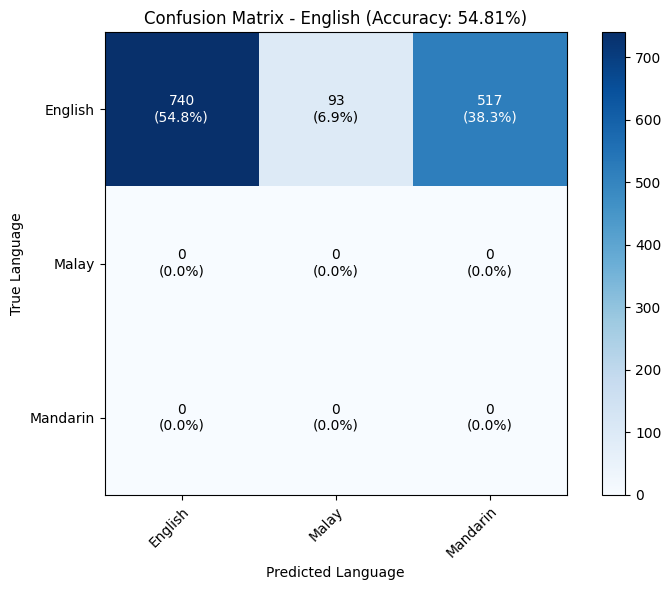

In [48]:
# Evaluate English subset only.
english_metrics = evaluate_language_subset(
    'English',
    LANG_MAP['en'],
    test_dataset_final,
    final_batch_size,
    model_path,
    PROJECT_ROOT
)

MALAY RESULTS
Samples: 1350
Accuracy: 67.26%
Classification Report:
              precision    recall  f1-score   support

     English     0.0000    0.0000    0.0000         0
       Malay     1.0000    0.6726    0.8043      1350
    Mandarin     0.0000    0.0000    0.0000         0

    accuracy                         0.6726      1350
   macro avg     0.3333    0.2242    0.2681      1350
weighted avg     1.0000    0.6726    0.8043      1350



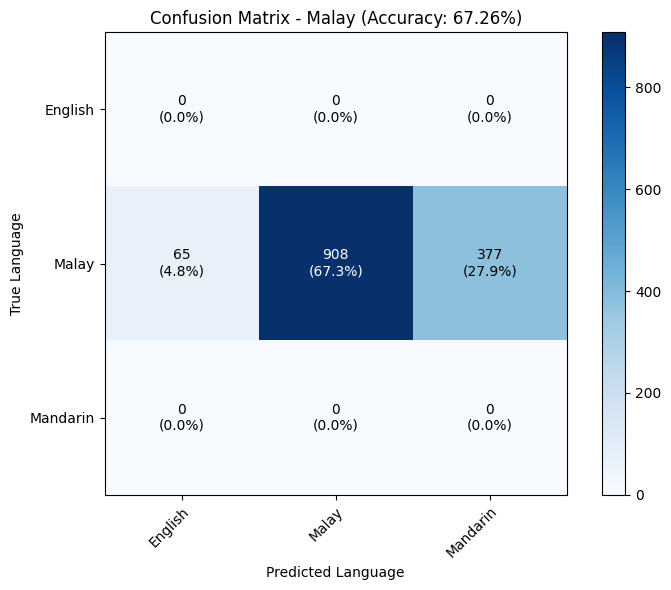

In [49]:
# Evaluate Malay subset only.
malay_metrics = evaluate_language_subset(
    'Malay',
    LANG_MAP['ms'],
    test_dataset_final,
    final_batch_size,
    model_path,
    PROJECT_ROOT
)

MANDARIN RESULTS
Samples: 1350
Accuracy: 98.59%
Classification Report:
              precision    recall  f1-score   support

     English     0.0000    0.0000    0.0000         0
       Malay     0.0000    0.0000    0.0000         0
    Mandarin     1.0000    0.9859    0.9929      1350

    accuracy                         0.9859      1350
   macro avg     0.3333    0.3286    0.3310      1350
weighted avg     1.0000    0.9859    0.9929      1350



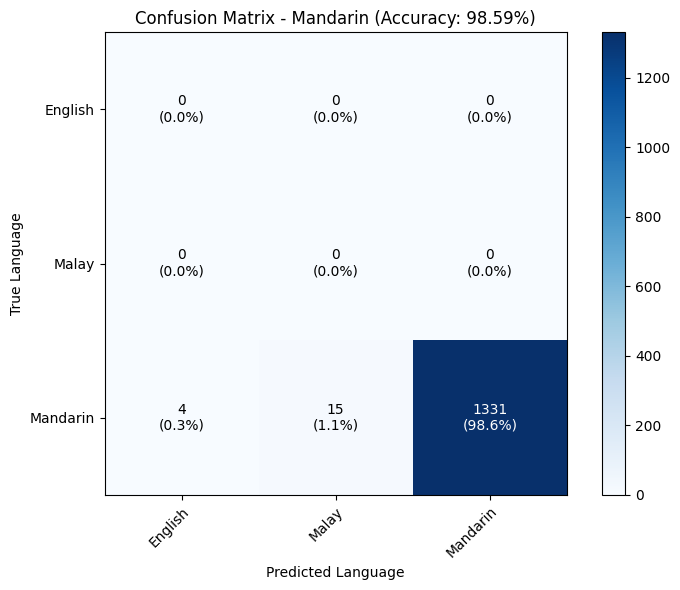

In [50]:
# Evaluate Mandarin subset only.
mandarin_metrics = evaluate_language_subset(
    'Mandarin',
    LANG_MAP['zh'],
    test_dataset_final,
    final_batch_size,
    model_path,
    PROJECT_ROOT
)

COMBINED TEST SUMMARY (ALL LANGUAGES)
Total samples: 4050
Overall accuracy: 73.56%
Classification Report:
              precision    recall  f1-score   support

     English     0.9147    0.5481    0.6855      1350
       Malay     0.8937    0.6726    0.7675      1350
    Mandarin     0.5982    0.9859    0.7446      1350

    accuracy                         0.7356      4050
   macro avg     0.8022    0.7356    0.7326      4050
weighted avg     0.8022    0.7356    0.7326      4050



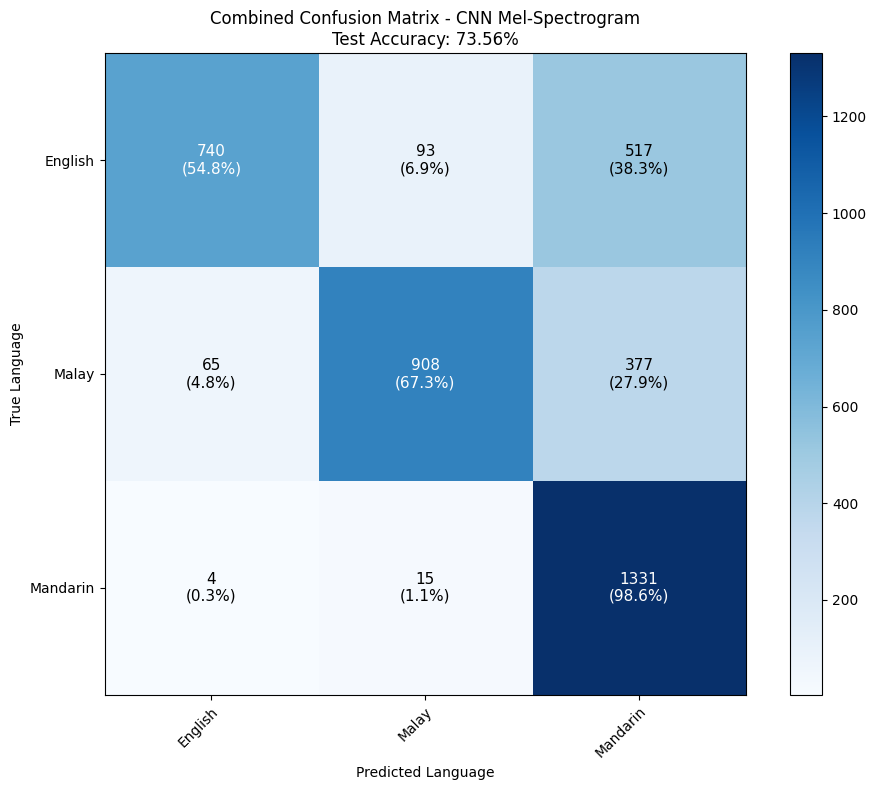

In [51]:
# Combined evaluation on all test samples (EN + MY + ZH) with one report and one confusion matrix.
all_test_loader = DataLoader(test_dataset_final, batch_size=final_batch_size, shuffle=False, num_workers=0)

combined_model = MelSpectrogramCNN(
    num_classes=len(LANG_MAP),
    dropout_fc1=float(best_config['dropout_fc1']),
    dropout_fc2=float(best_config['dropout_fc2'])
).to(device)
combined_model.load_state_dict(torch.load(model_path, map_location=device))
combined_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in all_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = combined_model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc = 100.0 * np.mean(all_labels == all_preds)

combined_report_text = classification_report(
    all_labels,
    all_preds,
    labels=list(LANG_MAP.values()),
    target_names=LANG_NAMES,
    digits=4,
    zero_division=0
)

cm = confusion_matrix(all_labels, all_preds, labels=list(LANG_MAP.values()))

print('=' * 60)
print('COMBINED TEST SUMMARY (ALL LANGUAGES)')
print('=' * 60)
print(f'Total samples: {len(all_labels)}')
print(f'Overall accuracy: {test_acc:.2f}%')
print('Classification Report:')
print(combined_report_text)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=LANG_NAMES,
    yticklabels=LANG_NAMES,
    title=f'Combined Confusion Matrix - CNN Mel-Spectrogram\nTest Accuracy: {test_acc:.2f}%',
    ylabel='True Language',
    xlabel='Predicted Language'
 )

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

thresh = cm.max() / 2.0 if cm.size > 0 else 0.0
for i in range(cm.shape[0]):
    row_total = cm[i].sum()
    for j in range(cm.shape[1]):
        percentage = (100.0 * cm[i, j] / row_total) if row_total > 0 else 0.0
        text = f'{cm[i, j]}\n({percentage:.1f}%)'
        ax.text(
            j, i, text,
            ha='center', va='center',
            color='white' if cm[i, j] > thresh else 'black',
            fontsize=11
        )

plt.tight_layout()
plt.show()

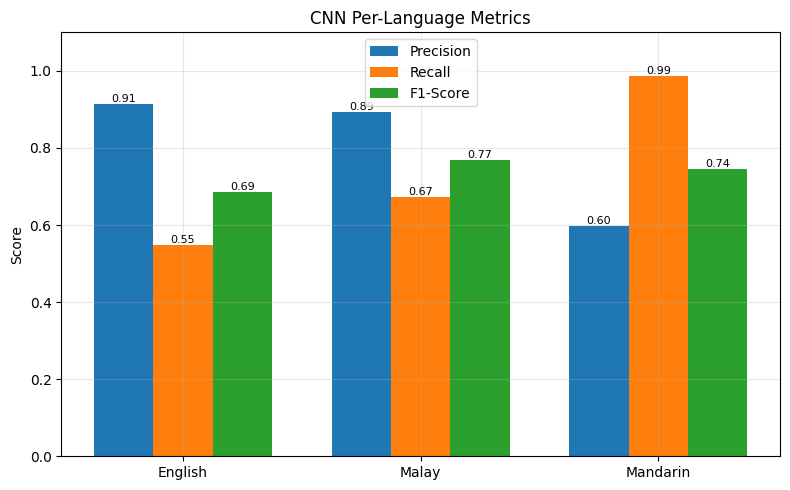

[Save] Per-language metrics: cnn_7p5h_per_language_metrics.png


In [2]:
# Visualization: CNN 7.5h Per-language metrics
import numpy as np
import matplotlib.pyplot as plt

LANG_NAMES = ['English', 'Malay', 'Mandarin']

# Newest CNN_7p5h combined results
precision = np.array([0.9147, 0.8937, 0.5982])
recall    = np.array([0.5481, 0.6726, 0.9859])
f1        = np.array([0.6855, 0.7675, 0.7446])

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(LANG_NAMES))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision')
bars2 = ax.bar(x, recall, width, label='Recall')
bars3 = ax.bar(x + width, f1, width, label='F1-Score')

ax.set_xticks(x)
ax.set_xticklabels(LANG_NAMES)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('CNN Per-Language Metrics')
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.savefig('cnn_7p5h_per_language_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('[Save] Per-language metrics: cnn_7p5h_per_language_metrics.png')

In [40]:
# Save a combined summary at the project root.
summary_path = PROJECT_ROOT / 'cnn_7p5h_language_summary.json'
summary_df = pd.DataFrame([
    {
        'language': name,
        'accuracy': metrics['accuracy'],
        'num_samples': metrics['num_samples'],
    }
    for name, metrics in language_eval_results.items()
])

combined_summary = {
    'tuning_source': TUNING_SOURCE,
    'final_run_source': FINAL_RUN_SOURCE,
    'best_config': best_config,
    'results': language_eval_results,
}

with open(summary_path, 'w') as f:
    json.dump(combined_summary, f, indent=2)

print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(summary_df.to_string(index=False))
print(f'Saved combined summary to: {summary_path}')

FINAL SUMMARY
language  accuracy  num_samples
 English 54.814815         1350
Mandarin 98.592593         1350
Saved combined summary to: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\cnn_7p5h_language_summary.json
